In [71]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Проверка наличия доступного ускорения GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое вычислительное устройство: {device}")

Используемое вычислительное устройство: cpu


In [72]:
# 1. Загрузка набора данных
# Предполагается, что каждая строка в наборе данных представляет собой один образец (временной ряд), а каждый столбец - временную точку
X_train_df = pd.read_csv('MI-EEG-B9Train.csv', header=None)
y_train_df = pd.read_csv('2class_MI_EEG_train_9.csv', header=None)

X_test_df = pd.read_csv('MI-EEG-B9Test.csv', header=None)
y_test_df = pd.read_csv('2class_MI_EEG_test_9.csv', header=None)

# Преобразование в массивы numpy
X_train = X_train_df.values
y_train = y_train_df.values.squeeze()
X_test = X_test_df.values
y_test = y_test_df.values.squeeze()

# Обработка меток, чтобы они начинались с 0 (если это 1 и 2, преобразовать в 0 и 1)
if y_train.min() > 0:
    y_train = y_train - y_train.min()
    y_test = y_test - y_test.min()

print(f"Форма сигналов обучающей выборки: {X_train.shape}, форма меток: {y_train.shape}")
print(f"Форма сигналов тестовой выборки: {X_test.shape}, форма меток: {y_test.shape}")

Форма сигналов обучающей выборки: (400, 3000), форма меток: (400,)
Форма сигналов тестовой выборки: (320, 3000), форма меток: (320,)


Выполняется вейвлет-преобразование, это может занять некоторое время...
Форма изображений обучающей выборки после преобразования: (400, 1, 32, 3000)


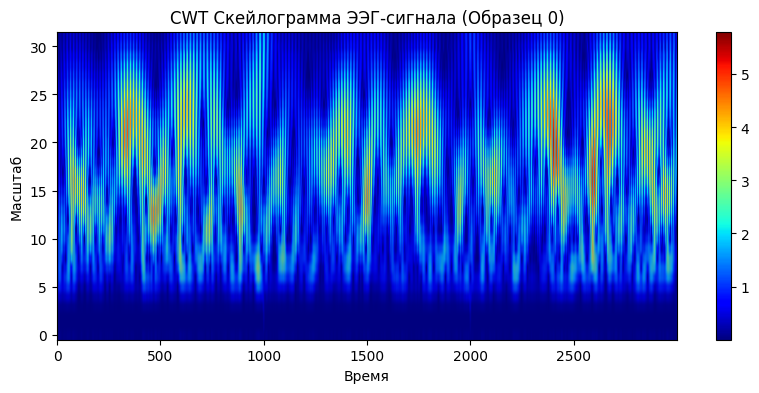

In [73]:
def apply_cwt(data, scales, wavelet_name='morl'):
    """
    Выполняет непрерывное вейвлет-преобразование одномерного ЭЭГ-сигнала,
    создаёт двумерную частотно-временную диаграмму
    data: shape (n_samples, n_timepoints)
    Возвращает: тензор изображения shape (n_samples, 1, n_scales, n_timepoints)
    """
    n_samples = data.shape[0]
    n_timepoints = data.shape[1]
    n_scales = len(scales)

    # Инициализация выходного массива с добавлением канального измерения (Channel=1)
    # для соответствия входу сверточной нейронной сети
    cwt_images = np.zeros((n_samples, 1, n_scales, n_timepoints))

    for i in range(n_samples):
        signal = data[i, :]
        # Выполнение непрерывного вейвлет-преобразования
        coefs, freqs = pywt.cwt(signal, scales, wavelet_name)
        # Использование абсолютного значения (амплитуды) как значения пикселя изображения
        cwt_images[i, 0, :, :] = np.abs(coefs)

    return cwt_images

# Определение масштабов для вейвлет-преобразования (определяет диапазон частот)
# Меньший масштаб соответствует высокой частоте; больший масштаб – низкой частоте.
# Здесь выбран диапазон от 1 до 32
scales = np.arange(1, 33)
print("Выполняется вейвлет-преобразование, это может занять некоторое время...")

X_train_cwt = apply_cwt(X_train, scales)
X_test_cwt = apply_cwt(X_test, scales)

print(f"Форма изображений обучающей выборки после преобразования: {X_train_cwt.shape}")

# Визуализация частотно-временной диаграммы одного образца
plt.figure(figsize=(10, 4))
plt.imshow(X_train_cwt[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
plt.title("CWT Скейлограмма ЭЭГ-сигнала (Образец 0)")
plt.ylabel("Масштаб")
plt.xlabel("Время")
plt.colorbar()
plt.show()

In [74]:
class EEGImageDataset(Dataset):
    def __init__(self, features, labels):

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = EEGImageDataset(X_train_cwt, y_train)
test_dataset = EEGImageDataset(X_test_cwt, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [75]:
class EEG_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(EEG_CNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2))
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2))
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)
        return x

model = EEG_CNN(num_classes=2).to(device)
print(model)

EEG_CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Начало обучения сети...
Эпоха [1/100], Потери: 0.7872, Точность: 0.4850
Эпоха [5/100], Потери: 0.6613, Точность: 0.6200
Эпоха [10/100], Потери: 0.6199, Точность: 0.6600
Эпоха [15/100], Потери: 0.5797, Точность: 0.6875
Эпоха [20/100], Потери: 0.5579, Точность: 0.7075
Эпоха [25/100], Потери: 0.5482, Точность: 0.7075
Эпоха [30/100], Потери: 0.5010, Точность: 0.7500
Эпоха [35/100], Потери: 0.4834, Точность: 0.7375
Эпоха [40/100], Потери: 0.4735, Точность: 0.7700
Эпоха [45/100], Потери: 0.4705, Точность: 0.7650
Эпоха [50/100], Потери: 0.5110, Точность: 0.7425
Эпоха [55/100], Потери: 0.4253, Точность: 0.7800
Эпоха [60/100], Потери: 0.4165, Точность: 0.7975
Эпоха [65/100], Потери: 0.4049, Точность: 0.8000
Эпоха [70/100], Потери: 0.3996, Точность: 0.7875
Эпоха [75/100], Потери: 0.3778, Точность: 0.8300
Эпоха [80/100], Потери: 0.4081, Точность: 0.7975
Эпоха [85/100], Потери: 0.3832, Точность: 0.8000
Эпоха [90/100], Потери: 0.4270, Точность: 0.8125
Эпоха [95/100], Потери: 0.3167, Точность: 0.855

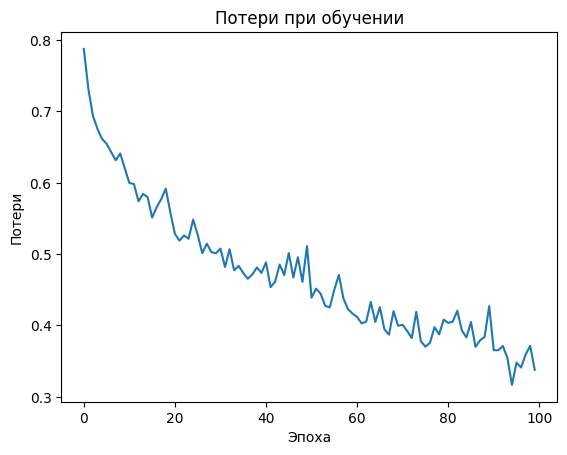

In [76]:
# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []

print("Начало обучения сети...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Обнуление градиентов
        optimizer.zero_grad()

        # Прямое распространение
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Обратное распространение и оптимизация
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}], Потери: {epoch_loss:.4f}, Точность: {epoch_acc:.4f}")

# Построение графика снижения потерь при обучении
plt.plot(train_losses)
plt.title('Потери при обучении')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.show()

In [77]:
# Оценка модели на тестовой выборке
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Итоговая точность на тестовой выборке (Accuracy): {acc * 100:.2f}%\n")
print("Детальный отчёт классификации:")
print(classification_report(all_labels, all_preds, target_names=['Левый кулак', 'Правый кулак']))

Итоговая точность на тестовой выборке (Accuracy): 77.19%

Детальный отчёт классификации:
              precision    recall  f1-score   support

 Левый кулак       0.74      0.85      0.79       160
Правый кулак       0.82      0.69      0.75       160

    accuracy                           0.77       320
   macro avg       0.78      0.77      0.77       320
weighted avg       0.78      0.77      0.77       320

